In [23]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [24]:
df = pd.read_csv("HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [25]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


(14999, 10)

In [26]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [27]:
df.describe(include = 'all')

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


In [28]:
groups = df.groupby('left').agg({
    'satisfaction_level': ['mean','median'],
    'last_evaluation': ['mean','median'],
    'number_project': ['mean','median'],
    'average_montly_hours': ['mean','median'],
    'time_spend_company': ['mean','median'],
    'promotion_last_5years': ['mean']
})
groups

satisfaction_level        last_evaluation        number_project         \
                   mean median            mean median           mean median   
left                                                                          
0              0.666810   0.69        0.715473   0.71       3.786664    4.0   
1              0.440098   0.41        0.718113   0.79       3.855503    4.0   

     average_montly_hours        time_spend_company         \
                     mean median               mean median   
left                                                         
0              199.060203  198.0           3.380032    3.0   
1              207.419210  224.0           3.876505    4.0   

     promotion_last_5years  
                      mean  
left                        
0                 0.026251  
1                 0.005321

In [29]:
numeric_cols = ['satisfaction_level','last_evaluation','number_project',
                'average_montly_hours','time_spend_company']
print(df[numeric_cols + ['left']].corr()['left'].sort_values())

satisfaction_level     -0.388375
last_evaluation         0.006567
number_project          0.023787
average_montly_hours    0.071287
time_spend_company      0.144822
left                    1.000000
Name: left, dtype: float64


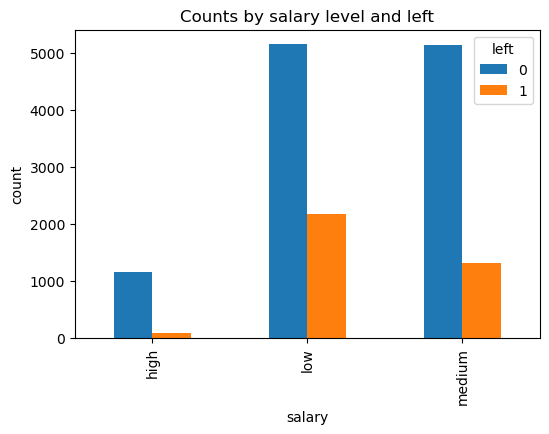

In [30]:
salary_left = df.groupby(['salary','left']).size().unstack(fill_value=0)
ax = salary_left.plot(kind='bar', stacked=False, figsize=(6,4))
ax.set_title("Counts by salary level and left")
ax.set_xlabel("salary")
ax.set_ylabel("count")
plt.show()

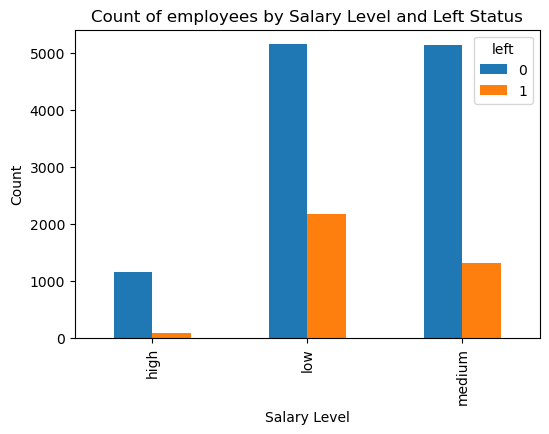

salary
low       0.296884
medium    0.204313
high      0.066289
Name: left, dtype: float64

In [31]:
salary_rates = df.groupby('salary')['left'].mean().sort_values(ascending=False)
salary_left.plot(kind='bar', figsize=(6,4))
plt.title("Count of employees by Salary Level and Left Status")
plt.xlabel("Salary Level")
plt.ylabel("Count")
plt.show()
salary_rates

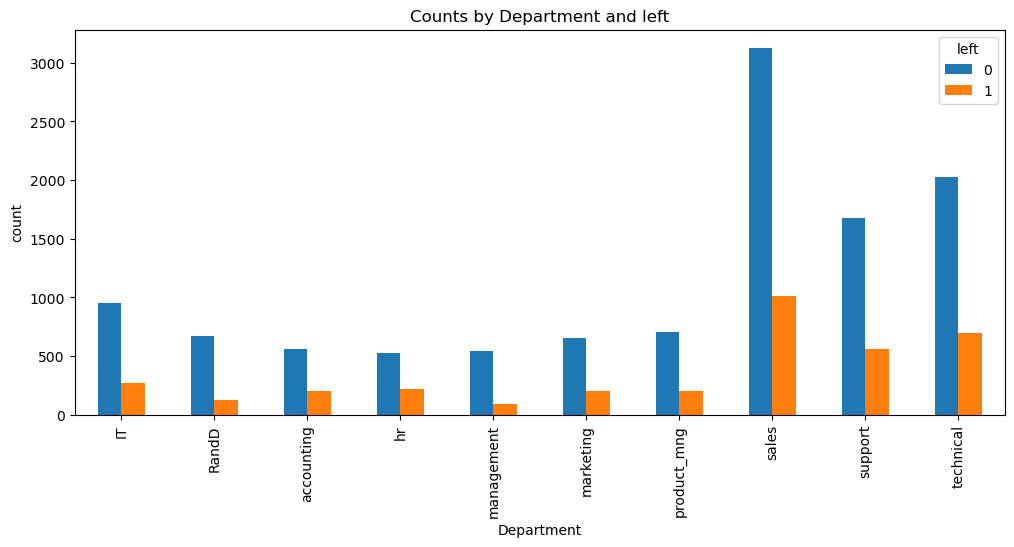

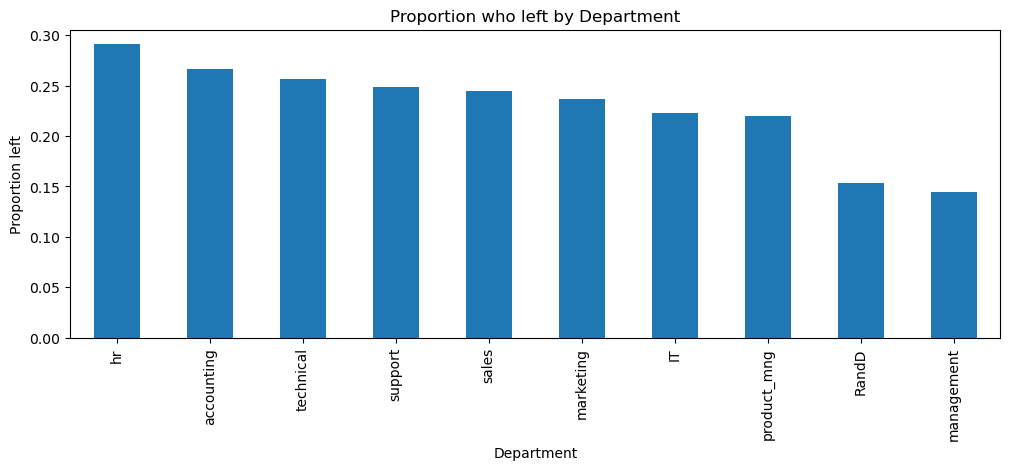

Top departments by proportion leaving:
 Department
hr             0.290934
accounting     0.265971
technical      0.256250
support        0.248991
sales          0.244928
marketing      0.236597
IT             0.222494
product_mng    0.219512
RandD          0.153748
management     0.144444
Name: left, dtype: float64


In [32]:
dept_left = df.groupby(['Department','left']).size().unstack(fill_value=0)
dept_left.plot(kind='bar', stacked=False, figsize=(12,5))
plt.title("Counts by Department and left")
plt.xlabel("Department")
plt.ylabel("count")
plt.show()

dept_rates = df.groupby('Department')['left'].mean().sort_values(ascending=False)
dept_rates.plot(kind='bar', figsize=(12,4))
plt.title("Proportion who left by Department")
plt.xlabel("Department")
plt.ylabel("Proportion left")
plt.show()

print("Top departments by proportion leaving:\n", dept_rates.head(10))

In [49]:
subdf = df[['satisfaction_level','number_project','average_montly_hours','promotion_last_5years','salary','left']]
subdf.head()

,satisfaction_level,number_project,average_montly_hours,promotion_last_5years,salary,left
0,0.38,2,157,0,low,1
1,0.80,5,262,0,medium,1
2,0.11,7,272,0,medium,1
3,0.72,5,223,0,low,1
4,0.37,2,159,0,low,1


In [40]:
salary_dummies = pd.get_dummies(subdf.salary, prefix="salary")
df_with_dummies = pd.concat([subdf,salary_dummies],axis='columns')
df_with_dummies.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary,salary_high,salary_low,salary_medium
0,0.38,157,0,low,False,True,False
1,0.80,262,0,medium,False,False,True
2,0.11,272,0,medium,False,False,True
3,0.72,223,0,low,False,True,False
4,0.37,159,0,low,False,True,False


In [41]:
df_with_dummies.drop('salary',axis='columns',inplace=True)
df_with_dummies.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,False,True,False
1,0.80,262,0,False,False,True
2,0.11,272,0,False,False,True
3,0.72,223,0,False,True,False
4,0.37,159,0,False,True,False


In [42]:
X = df_with_dummies
X.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,False,True,False
1,0.80,262,0,False,False,True
2,0.11,272,0,False,False,True
3,0.72,223,0,False,True,False
4,0.37,159,0,False,True,False


In [43]:
y = df.left

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.3)

In [45]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [46]:
model.fit(X_train, y_train)

LogisticRegression()

In [47]:
model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(10500,))

In [48]:
model.score(X_test,y_test)

0.7788571428571428